Assessment For Neural Network Regression using TensorFlow
Create your own regression dataset (or make the one we created in "Create data to view and fit" bigger) and build fit a model to it.
Try building a neural network with 4 Dense layers and fitting it to your own regression dataset, how does it perform?
Try and improve the results
Create the plot between predict and actual values
Please do not use exact same example as RegressionExample3
Upload your Google Colab Notebook to GitHub

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
range = np.random.seed(42)
n = 600
X = pd.DataFrame({
    'engine_size': np.random.normal(1800, 400, n).clip(800, 4000),
    'horsepower': np.random.normal(130, 40, n).clip(50, 400),
    'age_years': np.random.randint(0, 15, n)
})
noise = np.random.normal(0, 2000, n)
y=80*X['engine_size']+1500*X['horsepower']-1200*X['age_years']+5000+noise

In [5]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Transform the data
scaler = StandardScaler()
X_train_tr = scaler.fit_transform(X_train)
X_test_tr = scaler.transform(X_test)
print(X_train)
print(X_train_tr)

     engine_size  horsepower  age_years
145  2112.729149  100.970247          4
9    2017.024017  189.841772          4
375  1493.060975   54.418371          5
523  2028.239467   84.279803         14
188  1461.282513  127.193372          5
..           ...         ...        ...
71   2415.214627   50.000000          6
106  2554.474360   78.782826          6
270  2376.509316  122.922111          3
435  1829.637912  192.959471          9
102  1662.914193  101.826252          0

[480 rows x 3 columns]
[[ 0.84138447 -0.8119905  -0.6271361 ]
 [ 0.59484008  1.44104578 -0.6271361 ]
 [-0.75493238 -1.99215555 -0.39646535]
 ...
 [ 1.52090416 -0.25547541 -0.85780685]
 [ 0.11211786  1.52008445  0.52621765]
 [-0.31737633 -0.7902894  -1.54981909]]


In [7]:
# Model Creation
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_tr.shape[1],)),
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

In [8]:
model.compile(loss=tf.keras.losses.mse,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['mae'])

In [9]:
history = model.fit(X_train_tr, y_train, epochs=100, validation_data=(X_test_tr, y_test),batch_size=32)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 117552873472.0000 - mae: 336838.3125 - val_loss: 126623801344.0000 - val_mae: 349750.6562
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 117552553984.0000 - mae: 336838.0000 - val_loss: 126623309824.0000 - val_mae: 349750.1250
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 117552152576.0000 - mae: 336837.5312 - val_loss: 126622621696.0000 - val_mae: 349749.3438
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 117551538176.0000 - mae: 336836.7812 - val_loss: 126621581312.0000 - val_mae: 349748.0625
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 117550596096.0000 - mae: 336835.6875 - val_loss: 126620057600.0000 - val_mae: 349746.2188
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 117549228032.0000 - mae: 336834.0000 - val_loss: 126617894912.0000 - val_mae: 349743.5938
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 117547261952.0000 - mae: 336831.5312 - v

In [10]:
loss, mae = model.evaluate(X_test_tr, y_test,verbose=0)
print(f"Test Loss: {loss:.2f}")
print(f"Test MAE: {mae:.2f}")

Test Loss: 107143774208.00
Test MAE: 323921.53


In [11]:
y_predict = model.predict(X_test_tr)
print(y_predict)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[  7416.5312]
 [ 30043.412 ]
 [ 60404.01  ]
 [ 47892.7   ]
 [ -8046.1133]
 [ 51336.227 ]
 [ 29151.365 ]
 [ 21624.377 ]
 [ 38725.52  ]
 [ 24266.377 ]
 [ 31843.082 ]
 [ 26412.13  ]
 [ 51214.227 ]
 [ 39047.23  ]
 [ -9088.399 ]
 [ 40623.785 ]
 [-12156.877 ]
 [ 55703.684 ]
 [ 29527.754 ]
 [ 27007.85  ]
 [ 42058.05  ]
 [  9869.555 ]
 [ 37311.766 ]
 [ 20244.479 ]
 [ 20968.445 ]
 [ 28173.062 ]
 [ 16330.211 ]
 [ 44783.137 ]
 [  4735.086 ]
 [-15688.432 ]
 [ 23806.605 ]
 [ 11746.348 ]
 [ 26523.977 ]
 [ 24603.28  ]
 [ 27289.582 ]
 [ 31025.941 ]
 [ 20338.957 ]
 [ 35615.227 ]
 [ 13085.799 ]
 [ 56214.54  ]
 [ 27150.807 ]
 [ 38884.3   ]
 [ 26725.195 ]
 [ 36196.207 ]
 [ 45232.477 ]
 [ 19787.104 ]
 [ 12509.748 ]
 [ -5516.8105]
 [   796.3397]
 [ 21539.299 ]
 [ 27761.81  ]
 [ 26453.717 ]
 [ 35837.246 ]
 [ 36000.668 ]
 [ -5163.952 ]
 [ 26583.201 ]
 [ 40360.93  ]
 [ 13903.302 ]
 [ 35790.996 ]
 [ 43357.863 ]
 [  4264.701 ]
 [  9521.481 ]
 [ 25318.303 ]
 [ 33502.05  ]
 [

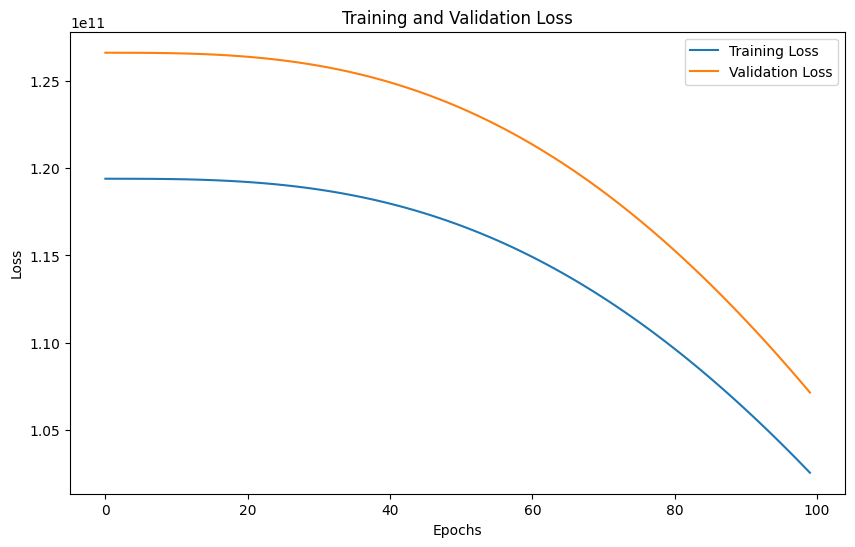

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

In [13]:
y_predict = model.predict(X_test_tr)
print(y_test.values)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
[282770.41405143 367169.68164372 474973.00988986 424559.54362817
 231461.14485851 436762.50743431 366055.32326857 328314.60110941
 398274.33118197 344583.79461446 374209.77004451 352956.88590703
 441620.20111417 398244.34944503 225854.22413038 401128.39283082
 211897.79749481 458276.84158269 359575.08084865 352681.41419436
 406163.34612609 291270.82344612 386985.62173738 332439.78333517
 330778.85664903 353544.70790793 321215.922671   420249.56213799
 273253.41849256 200250.06848723 341959.13505635 297579.52624815
 349799.74445877 349994.57296501 349107.50082125 365597.3603861
 330635.13188233 385987.35055356 301269.30176139 459061.97820101
 355102.24237312 402026.91240486 353039.22578557 390141.03208657
 423610.6249953  333962.2569151  307028.77026716 240231.72574017
 259117.77504065 336799.56432064 360530.74215875 350306.0375065
 386636.12159397 386282.09976434 239104.18997117 348012.79712705
 398493.44584309 306797.53204956 384824.96082967 41363

In [14]:
print(y_test.shape)
print(y_predict.shape)

(120,)
(120, 1)


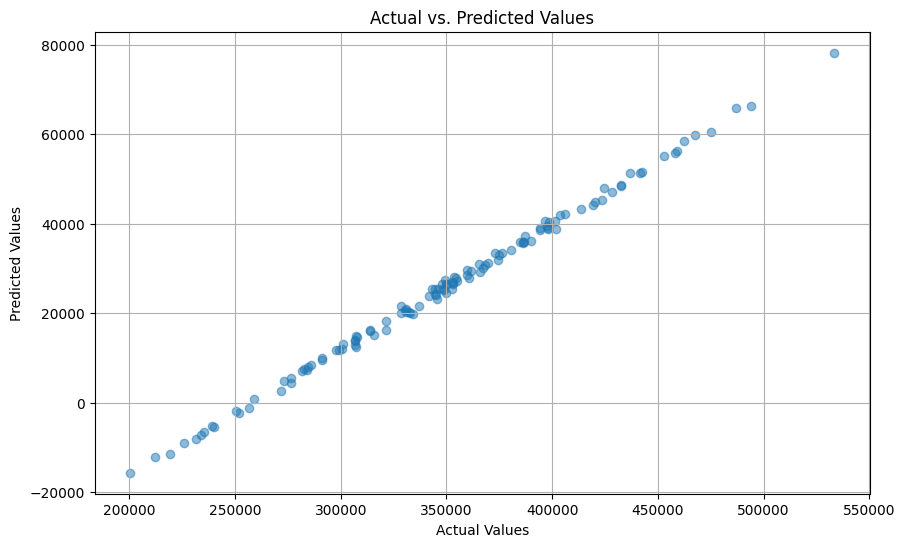

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test.values, y_predict, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.grid(True)
plt.show()